# Data Visualization

## Seaborn Plot Demonstrations

In [73]:
frames = []
unique_times = df['time'].unique()

for t in unique_times:
    temp_df = df[df['time'] <= t].copy()
    temp_df['frame_time'] = t.strftime('%Y-%m-%d') # The slider label
    frames.append(temp_df)

cumulative_df = pd.concat(frames)

fig = px.scatter(
    cumulative_df,
    x='x',
    y='y',
    animation_frame='frame_time',
    color='hue_cat',
    size='value',
    hover_name='category',
    range_x=[0, 11],
    range_y=[0, 13],
    title="Example Scatter Plot with Slider",
    color_discrete_map={'Group 1': 'steelblue', 'Group 2': 'orange'},
    template="plotly_white"
)

# Speed up the animation for a smoother "build-up" effect
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 100
fig.show()

### 1. Seaborn Scatter Plot

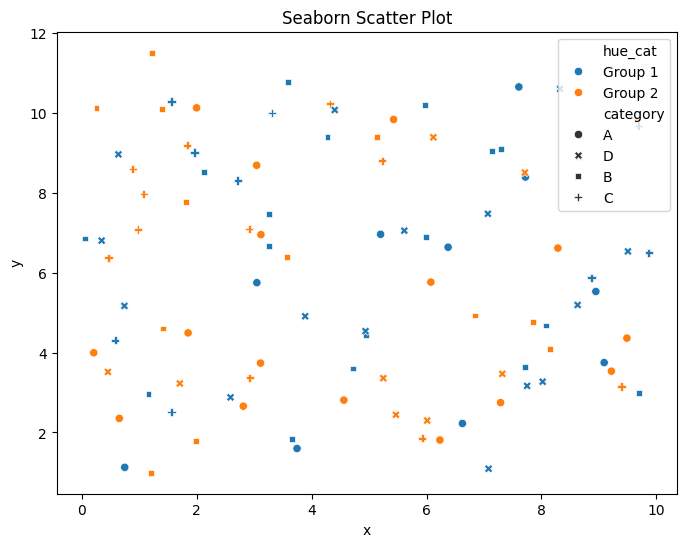

In [74]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='x', y='y', hue='hue_cat', style='category')
plt.title('Seaborn Scatter Plot')
plt.show()

### 2. Seaborn Line Plot

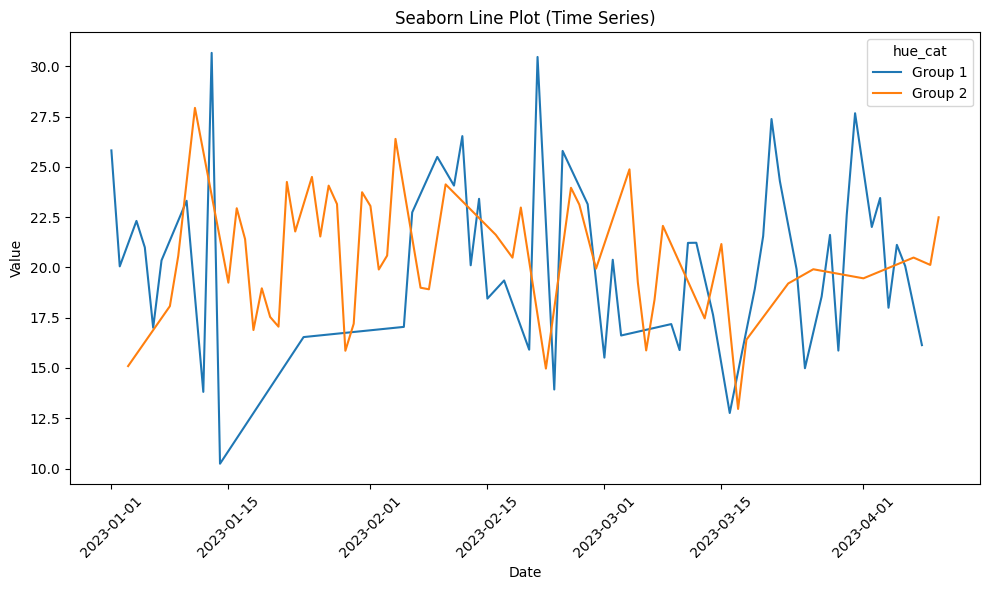

In [75]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df.sort_values('time'), x='time', y='value', hue='hue_cat', errorbar=None)
plt.title('Seaborn Line Plot (Time Series)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Seaborn Bar Plot

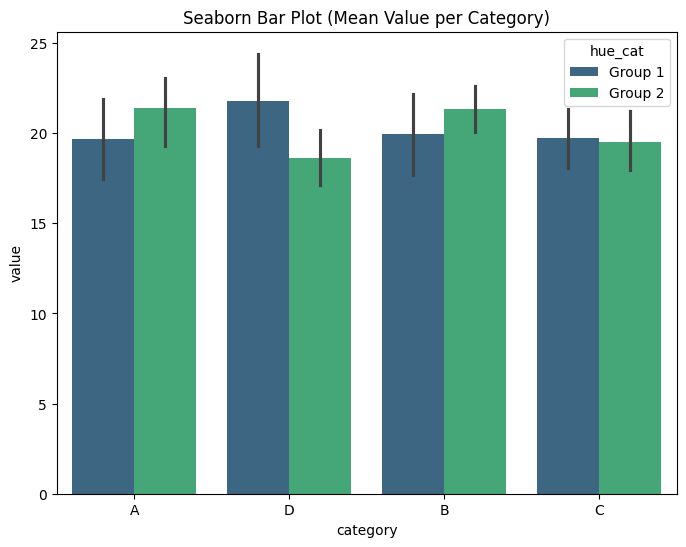

In [76]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='category', y='value', estimator=np.mean, hue='hue_cat', palette='viridis')
plt.title('Seaborn Bar Plot (Mean Value per Category)')
plt.show()

### 4. Seaborn Histogram (Distribution Plot)

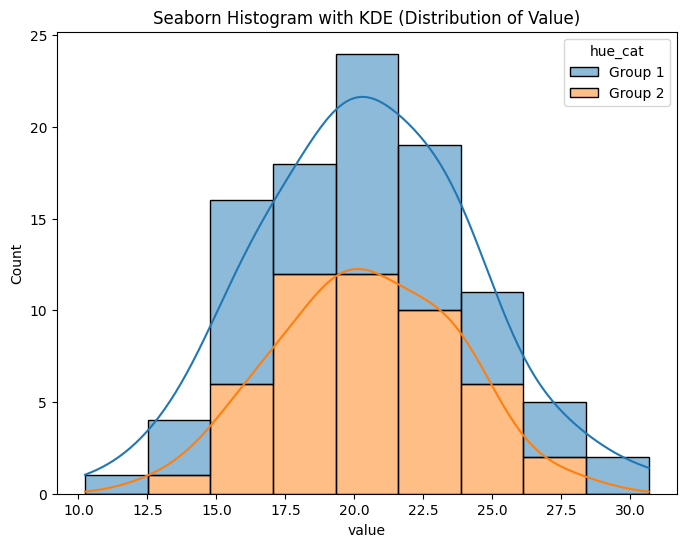

In [77]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='value', kde=True, hue='hue_cat', multiple='stack')
plt.title('Seaborn Histogram with KDE (Distribution of Value)')
plt.show()

### 5. Seaborn Box Plot

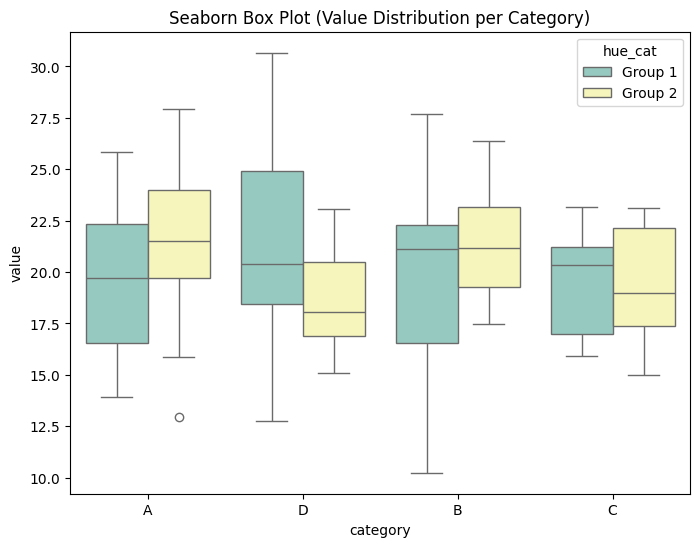

In [78]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='category', y='value', hue='hue_cat', palette='Set3')
plt.title('Seaborn Box Plot (Value Distribution per Category)')
plt.show()

### 6. Seaborn Violin Plot

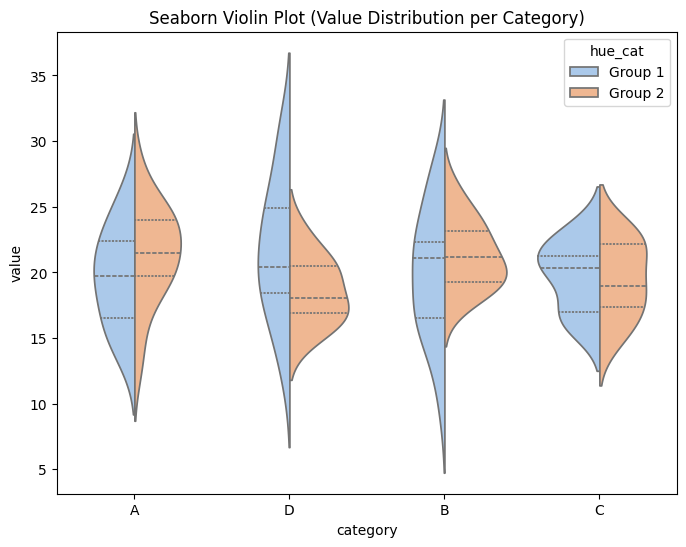

In [79]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='category', y='value', hue='hue_cat', split=True, inner='quart', palette='pastel')
plt.title('Seaborn Violin Plot (Value Distribution per Category)')
plt.show()

### 7. Seaborn Heatmap

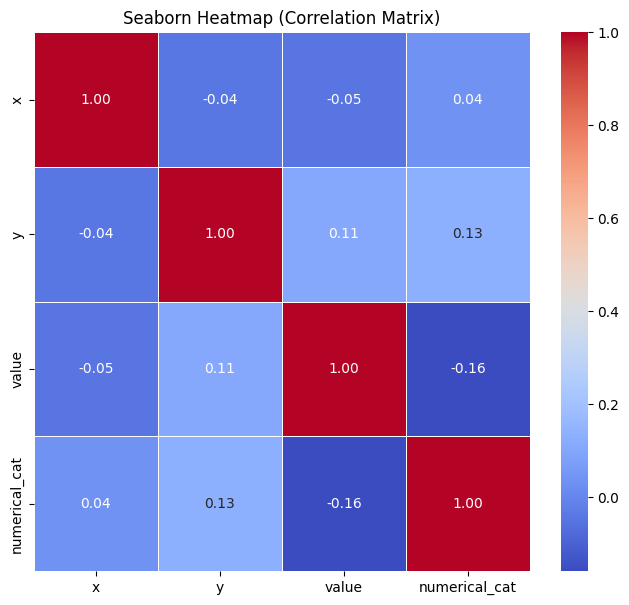

In [80]:
plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Seaborn Heatmap (Correlation Matrix)')
plt.show()

### 8. Seaborn Pair Plot

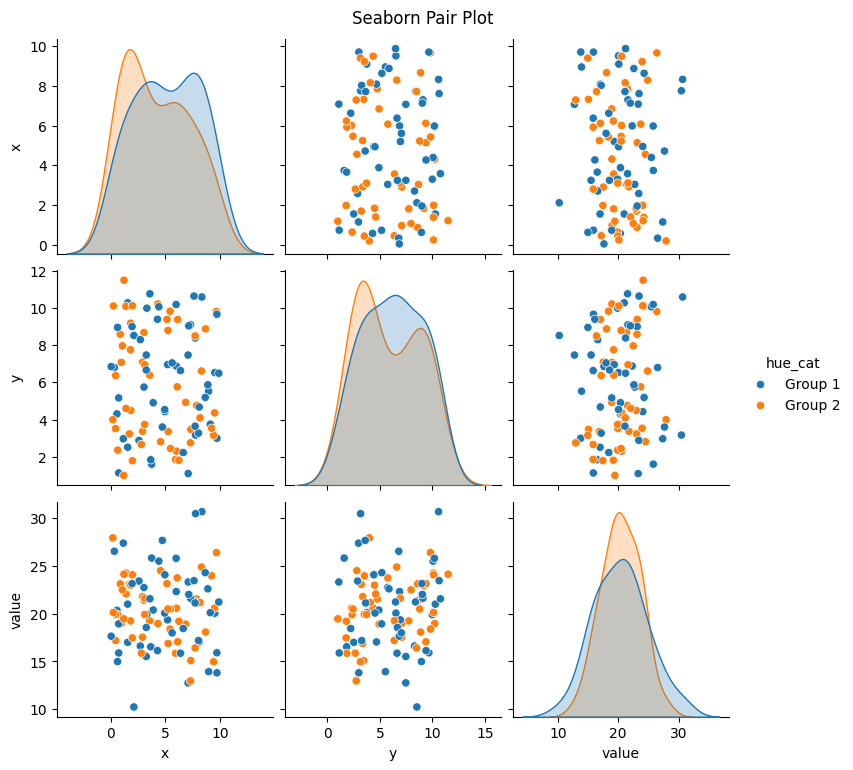

In [81]:
pair_plot_df = df[['x', 'y', 'value', 'hue_cat']]
sns.pairplot(pair_plot_df, hue='hue_cat', diag_kind='kde')
plt.suptitle('Seaborn Pair Plot', y=1.02)
plt.show()

## Plotly Plot Demonstrations

In [82]:
import plotly.express as px
import plotly.graph_objects as go

print("Using the same sample data for Plotly:")
display(df.head())

Using the same sample data for Plotly:


,x,y,category,value,hue_cat,time,numerical_cat
0,3.745401,1.598355,A,25.815819,Group 1,2023-01-01,1
1,9.507143,6.532384,D,20.051165,Group 1,2023-01-02,1
2,7.319939,3.466817,D,15.092457,Group 2,2023-01-03,3
3,5.986585,6.882815,B,22.310517,Group 1,2023-01-04,1
4,1.560186,10.288523,C,20.995298,Group 1,2023-01-05,2


### 1. Plotly Scatter Plot

In [83]:
fig = px.scatter(df, x='x', y='y', color='hue_cat', symbol='category', title='Plotly Scatter Plot')
fig.show()

### 2. Plotly Line Plot

In [84]:
fig = px.line(df.sort_values('time'), x='time', y='value', color='hue_cat', title='Plotly Line Plot (Time Series)')
fig.show()

### 3. Plotly Bar Chart

In [85]:
avg_value_cat = df.groupby(['category', 'hue_cat'], as_index=False)['value'].mean()
fig = px.bar(avg_value_cat, x='category', y='value', color='hue_cat', barmode='group', title='Plotly Bar Chart (Mean Value per Category)')
fig.show()

### 4. Plotly Histogram

In [86]:
fig = px.histogram(df, x='value', color='hue_cat', marginal='box', title='Plotly Histogram (Distribution of Value)')
fig.show()

### 5. Plotly Box Plot

In [87]:
fig = px.box(df, x='category', y='value', color='hue_cat', title='Plotly Box Plot (Value Distribution per Category)')
fig.show()

### 6. Plotly Violin Plot

In [88]:
fig = px.violin(df, x='category', y='value', color='hue_cat', box=True, points='all', title='Plotly Violin Plot (Value Distribution per Category)')
fig.show()

### 7. Plotly Heatmap

In [89]:
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.index,
    colorscale='Viridis'))
fig.update_layout(title='Plotly Heatmap (Correlation Matrix)')
fig.show()

### 8. Plotly Pie Chart

In [90]:
category_counts = df['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']
fig = px.pie(category_counts, values='count', names='category', title='Plotly Pie Chart (Distribution of Categories)')
fig.show()

### 9. Plotly 3D Scatter Plot

In [91]:
fig = px.scatter_3d(df, x='x', y='y', z='value', color='hue_cat', symbol='category', title='Plotly 3D Scatter Plot')
fig.show()

### 10. Plotly Sunburst Chart

In [92]:
fig = px.sunburst(df, path=['hue_cat', 'category'], values='value', title='Plotly Sunburst Chart (Value by Category Hierarchy)')
fig.show()

### 11. Plotly Density Heatmap (2D Histogram)

In [93]:
fig = px.density_heatmap(df, x='x', y='y', marginal_x='histogram', marginal_y='histogram', title='Plotly Density Heatmap of X and Y')
fig.show()

### 12. Plotly Interactive Scatter Plot with Slider

In [94]:
import pandas as pd
import plotly.express as px

# Add a unique ID for each row to be used as animation_group
df_with_id = df.reset_index().rename(columns={'index': 'unique_id'})

unique_times = sorted(df_with_id['time'].unique())
cumulative_data = []

for i, current_time in enumerate(unique_times):
    # Get all data up to the current_time
    df_upto_current_time = df_with_id[df_with_id['time'] <= current_time].copy()
    # Add a column to identify the animation frame
    df_upto_current_time['animation_step'] = current_time
    cumulative_data.append(df_upto_current_time)

cumulative_df = pd.concat(cumulative_data)

print("Unique categories in cumulative_df for symbol mapping:")
display(cumulative_df['category'].unique())
print("Unique hue_cat values in cumulative_df for color mapping:")
display(cumulative_df['hue_cat'].unique())

fig = px.scatter(cumulative_df, x='x', y='y', animation_frame='animation_step',
                 animation_group='unique_id', # Changed animation_group to a unique ID
                 color='hue_cat', symbol='category', hover_name='category',
                 title='Plotly Interactive Scatter Plot (Cumulative Over Time)')
fig.update_layout(xaxis_range=[df['x'].min()-1, df['x'].max()+1], yaxis_range=[df['y'].min()-1, df['y'].max()+1])
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1000
fig.show()

Unique categories in cumulative_df for symbol mapping:


array(['A', 'D', 'B', 'C'], dtype=object)

Unique hue_cat values in cumulative_df for color mapping:


array(['Group 1', 'Group 2'], dtype=object)

In [95]:
print("Unique categories in the data for the slider plot:")
display(cumulative_df['category'].unique())

Unique categories in the data for the slider plot:


array(['A', 'D', 'B', 'C'], dtype=object)

### 13. Plotly Scatter Plot with Dropdown Filtering by Category

In [96]:
import plotly.graph_objects as go
import plotly.express as px # Import plotly.express for its color palettes

# Get unique categories
unique_categories = df['category'].unique()

# Create initial figure
fig = go.Figure()

# Define a color palette for the categories
colors = px.colors.qualitative.Plotly # Using a standard Plotly qualitative palette

# Add a trace for each category, initially hidden
for i, cat in enumerate(unique_categories):
    df_cat = df[df['category'] == cat]
    fig.add_trace(go.Scatter(
        x=df_cat['x'],
        y=df_cat['y'],
        mode='markers',
        name=cat,
        marker=dict(size=10, color=colors[i % len(colors)]), # Assign a unique color from the palette
        visible=False # Initially hide all traces
    ))

# Create buttons for the dropdown menu
buttons = [
    dict(label="All",
         method="update",
         args=[
             {"visible": [True] * len(unique_categories)},
             {"title": "Plotly Scatter Plot (All Categories)"}
         ]
    )
]

for i, cat in enumerate(unique_categories):
    visibility = [False] * len(unique_categories)
    visibility[i] = True # Only this category visible
    buttons.append(dict(label=cat,
                        method="update",
                        args=[
                            {"visible": visibility},
                            {"title": f"Plotly Scatter Plot (Category: {cat})"}
                        ]
    ))

# Add dropdown menu to the layout
fig.update_layout(
    title='Plotly Scatter Plot with Category Dropdown',
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.0,
            xanchor="left",
            y=1.15,
            yanchor="top",
            active=0 # Set 'All' as the default active button
        )
    ],
    showlegend=True # Add this line to show the legend
)

fig.show()